<a href="https://colab.research.google.com/github/MUKESHKUMAR-21/DeepLearning/blob/main/DL_Exp02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Testing: Layers=[8], Activation=relu
-> Test Accuracy: 0.9667

Testing: Layers=[8], Activation=tanh
-> Test Accuracy: 0.9667

Testing: Layers=[8], Activation=sigmoid
-> Test Accuracy: 0.9333

Testing: Layers=[16, 8], Activation=relu
-> Test Accuracy: 0.9667

Testing: Layers=[16, 8], Activation=tanh
-> Test Accuracy: 0.9667

Testing: Layers=[16, 8], Activation=sigmoid
-> Test Accuracy: 0.9000

Testing: Layers=[32, 16, 8], Activation=relu
-> Test Accuracy: 1.0000

Testing: Layers=[32, 16, 8], Activation=tanh
-> Test Accuracy: 1.0000

Testing: Layers=[32, 16, 8], Activation=sigmoid
-> Test Accuracy: 0.9333

🏆 Best Config: [32, 16, 8] with relu (Acc: 1.0000)


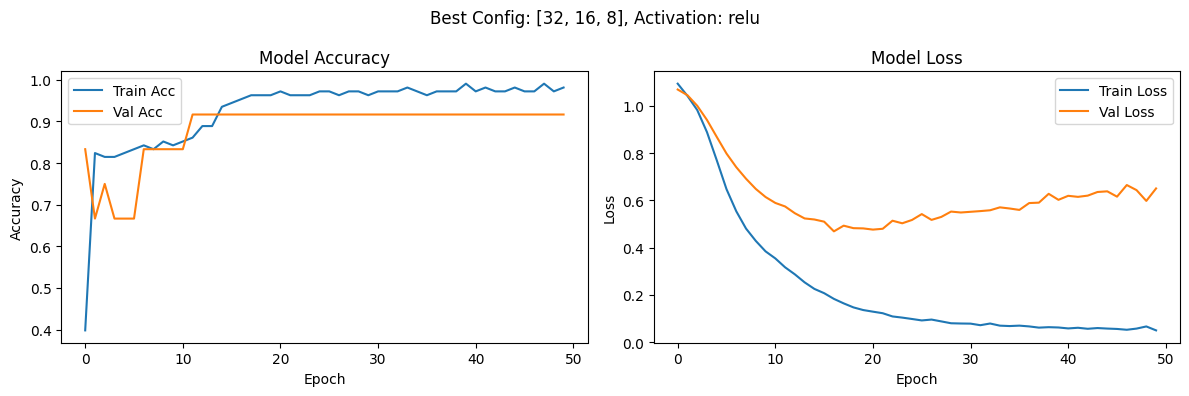


--- Iris Species Predictor ---
Sepal length (cm): 25
Sepal width (cm): 6
Petal length (cm): 20
Petal width (cm): 4

🌸 Predicted Iris Species: virginica


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.layers import Dense, Input # Import Input
from tensorflow.keras.models import Sequential


def prepare_data():
    """Loads, scales, and splits the Iris dataset."""
    iris = load_iris()
    X, y = iris.data, iris.target.reshape(-1, 1)

    # One-hot encode targets and scale features
    encoder = OneHotEncoder(sparse_output=False)
    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)
    y_encoded = encoder.fit_transform(y)

    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test, scaler, iris.target_names


def create_mlp(input_dim, output_dim, hidden_layers, activation="relu"):
    """Builds and compiles a Sequential MLP model."""
    model = Sequential()

    # Input layer - Modified to use Input(shape)
    model.add(Input(shape=(input_dim,))) # This replaces input_dim in the first Dense layer

    model.add(Dense(hidden_layers[0], activation=activation)) # No input_dim here

    # Hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation)
    )

    # Output layer
    model.add(Dense(output_dim, activation="softmax"))

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


def evaluate_configurations(X_train, y_train, X_test, y_test):
    """Grid searches configurations and returns the best performing model."""
    hidden_layer_configs = [[8], [16, 8], [32, 16, 8]]
    activations = ["relu", "tanh", "sigmoid"]

    best_acc = -1
    best_model = None
    best_history = None
    best_config = {}

    for hidden_layers in hidden_layer_configs:
        for activation in activations:
            print(f"\nTesting: Layers={hidden_layers}, Activation={activation}")

            model = create_mlp(
                input_dim=4,
                output_dim=3,
                hidden_layers=hidden_layers,
                activation=activation,
            )

            # Added validation_data explicitly to avoid split artifacts
            history = model.fit(
                X_train,
                y_train,
                epochs=50,
                batch_size=5,
                verbose=0,
                validation_split=0.1,
            )

            _, test_acc = model.evaluate(X_test, y_test, verbose=0)
            print(f"-> Test Accuracy: {test_acc:.4f}")

            # Keep track of the absolute best model instead of just the last one
            if test_acc > best_acc:
                best_acc = test_acc
                best_model = model
                best_history = history
                best_config = {
                    "layers": hidden_layers,
                    "activation": activation,
                }

    print(
        f"\n Best Config: {best_config['layers']} with {best_config['activation']} (Acc: {best_acc:.4f})"
    )
    return best_model, best_history, best_config


def plot_metrics(history, config):
    """Plots training and validation metrics for the best model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(
        f"Best Config: {config['layers']}, Activation: {config['activation']}",
        fontsize=12,
    )

    # Accuracy subplot
    ax1.plot(history.history["accuracy"], label="Train Acc")
    ax1.plot(history.history["val_accuracy"], label="Val Acc")
    ax1.set_title("Model Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    # Loss subplot
    ax2.plot(history.history["loss"], label="Train Loss")
    ax2.plot(history.history["val_loss"], label="Val Loss")
    ax2.set_title("Model Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()


def predict_user_input(model, scaler, classes):
    """Takes user inputs to make a live prediction."""
    print("\n--- Iris Species Predictor ---")
    try:
        inputs = [
            float(input("Sepal length (cm): ")),
            float(input("Sepal width (cm): ")),
            float(input("Petal length (cm): ")),
            float(input("Petal width (cm): ")),
        ]
    except ValueError:
        print("Invalid numeric input.")
        return

    user_input = np.array([inputs])
    user_input_scaled = scaler.transform(user_input)

    prediction = model.predict(user_input_scaled, verbose=0)
    predicted_class = classes[np.argmax(prediction)]

    print(f"\n Predicted Iris Species: {predicted_class}")


# --- Main Execution Pipeline ---
if __name__ == "__main__":
    X_train, X_test, y_train, y_test, scaler, classes = prepare_data()

    # Run hyperparameter evaluation
    best_model, best_history, best_config = evaluate_configurations(
        X_train, y_train, X_test, y_test
    )

    # Plot performance of the winning configuration
    if best_history:
        plot_metrics(best_history, best_config)

    # Predict custom input using the winning model
    if best_model:
        predict_user_input(best_model, scaler, classes)